In [14]:
import sys, os
from google.colab import drive
drive.mount('/content/drive')
sys.path.insert(0, '/content/drive/MyDrive/DiabeticRetinopathyDL')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import os

from utils import *

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [16]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [17]:
import kagglehub
import shutil

# For copying to local folder
destination = "./dataset"

if not os.path.exists(destination): # Skips downloading dataset if dataset folder already exists
    # Download dataset
    path = kagglehub.dataset_download("sachinkumar413/diabetic-retinopathy-dataset")
    print("Downloaded to:", path)

    shutil.copytree(path, destination, dirs_exist_ok=True)
    print("Copied to:", destination)

    # Check structure
    for root, dirs, files in os.walk(destination):
        print("Current path:", root)
        print("Folders:", dirs)
        print("------")
        break

    # Remove unwanted folders
    folders_to_remove = ["Mild DR", "Moderate DR", "Proliferate DR"]

    for folder in folders_to_remove:
        folder_path = os.path.join(destination, folder)

        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)
            print(f"Removed: {folder_path}")
        else:
            print(f"Folder not found: {folder_path}")
else:
    print("Dataset folder already exists, ignoring...")

Dataset folder already exists, ignoring...


In [18]:
complete_path = "./dataset/.complete"

if os.path.exists(complete_path):
    shutil.rmtree(complete_path)
    print("Removed .complete folder")

In [19]:
# EfficientNet-B0 requires 224x224 input with ImageNet normalization
transforms_efficientnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# full_dataset[i] is a tuple of (image tensor, class index)
full_dataset = torchvision.datasets.DatasetFolder(root="./dataset", loader=torchvision.datasets.folder.default_loader, transform=transforms_efficientnet, extensions=[".png"])

In [20]:
print("Classes:", full_dataset.class_to_idx)
print("Total dataset size:", len(full_dataset))

healthy = 0
severe = 0
for data in full_dataset:
    if data[1] == 0:
        healthy += 1
    elif data[1] == 1:
        severe += 1
print("Total 'Healthy' samples:", healthy)
print("Total 'Severe' samples:", severe)

Classes: {'Healthy': 0, 'Severe DR': 1}
Total dataset size: 1190
Total 'Healthy' samples: 1000
Total 'Severe' samples: 190


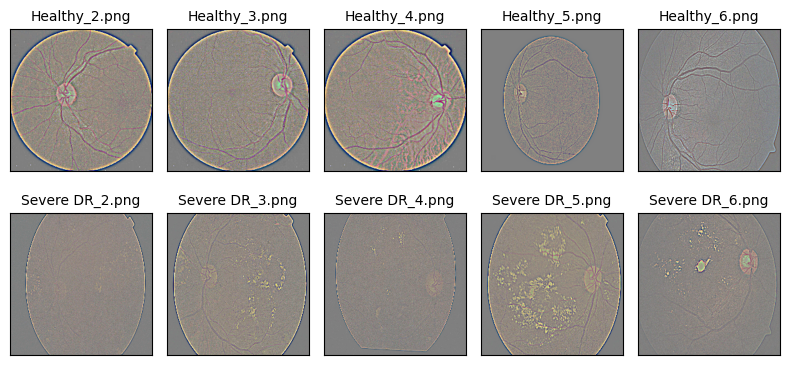

In [21]:
'''
Plots images for dataset visualization
'''

fig, axes = plt.subplots(2, 5, figsize=(8,4))

for idx in range(5):
    # Set all axes to hug left (west)
    axes[0][idx].set_anchor('W')
    axes[1][idx].set_anchor('W')

    # 'Healthy' Images
    axes[0][idx].set_xticks([])
    axes[0][idx].set_yticks([])
    healthy_fp = "Healthy_{}.png".format(idx+2)
    _ = axes[0][idx].set_title(healthy_fp, fontsize=10)
    img = plt.imread("./dataset/Healthy/{}".format(healthy_fp))
    axes[0][idx].imshow(img)

    # 'Severe DR' Images
    axes[1][idx].set_xticks([])
    axes[1][idx].set_yticks([])
    severe_fp = "Severe DR_{}.png".format(idx+2)
    _ = axes[1][idx].set_title(severe_fp, fontsize=10)
    img = plt.imread("./dataset/Severe DR/{}".format(severe_fp))
    axes[1][idx].imshow(img)

plt.tight_layout()
plt.show()

In [22]:
'''
Training-Test-Validation Split
Train dataset: 80% of 'Healthy' + 80% of 'Severe'
Test dataset: 10% of 'Healthy' + 10% of 'Severe'
Validation dataset: 10% of 'Healthy' + 10% of 'Severe'
'''

targets = full_dataset.targets
train_indices = []
test_indices = []
validation_indices = []

for c in range(len(full_dataset.classes)):
    class_indices = [i for i, t in enumerate(targets) if t==c]
    torch.manual_seed(42)
    perm = torch.randperm(len(class_indices)).tolist()
    if c == 0:
        r = healthy
    else:
        r = severe
    a = int(r*0.8)
    b = int(r*0.9)
    train_indices.extend([class_indices[p] for p in perm[:a]])
    test_indices.extend([class_indices[p] for p in perm[a:b]])
    validation_indices.extend([class_indices[p] for p in perm[b:r]])

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
test_dataset = torch.utils.data.Subset(full_dataset, test_indices)
validation_dataset = torch.utils.data.Subset(full_dataset, validation_indices)

In [23]:
# Dataloaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)
validation_dataloader = DataLoader(validation_dataset, batch_size, shuffle=False)

In [24]:
torch.manual_seed(42)
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# Replace the classifier head for binary classification (Healthy vs Severe DR)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

Epoch [1/20]:
 Training Loss: 0.160029   | Training Accuracy: 0.9296
 Validation Loss: 0.026387 | Validation Accuracy: 1.0000
Epoch [2/20]:
 Training Loss: 0.074240   | Training Accuracy: 0.9748
 Validation Loss: 0.036830 | Validation Accuracy: 0.9832
Epoch [3/20]:
 Training Loss: 0.070562   | Training Accuracy: 0.9727
 Validation Loss: 0.030001 | Validation Accuracy: 0.9916
Epoch [4/20]:
 Training Loss: 0.036970   | Training Accuracy: 0.9874
 Validation Loss: 0.032196 | Validation Accuracy: 0.9832
Epoch [5/20]:
 Training Loss: 0.020875   | Training Accuracy: 0.9895
 Validation Loss: 0.054557 | Validation Accuracy: 0.9832
Epoch [6/20]:
 Training Loss: 0.019692   | Training Accuracy: 0.9958
 Validation Loss: 0.024722 | Validation Accuracy: 0.9832
Epoch [7/20]:
 Training Loss: 0.012297   | Training Accuracy: 0.9989
 Validation Loss: 0.004336 | Validation Accuracy: 1.0000
Epoch [8/20]:
 Training Loss: 0.011835   | Training Accuracy: 0.9979
 Validation Loss: 0.028469 | Validation Accuracy:

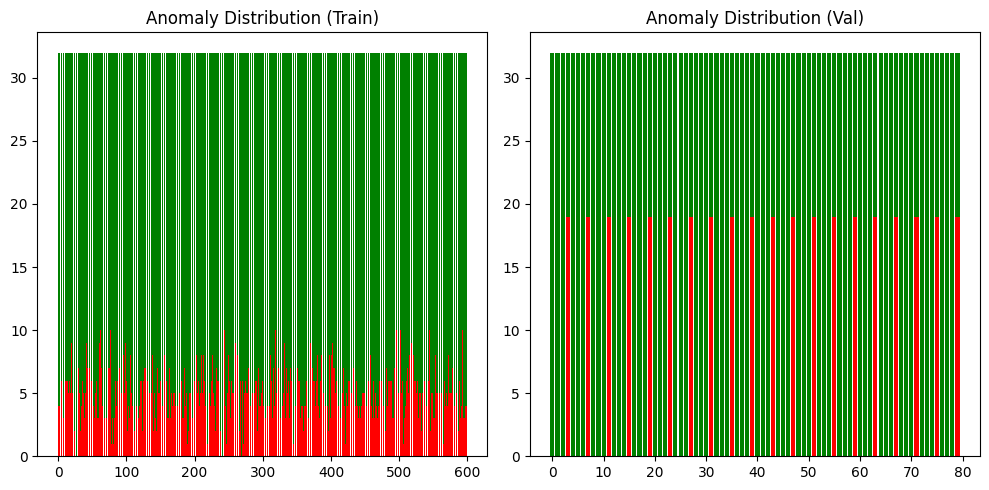

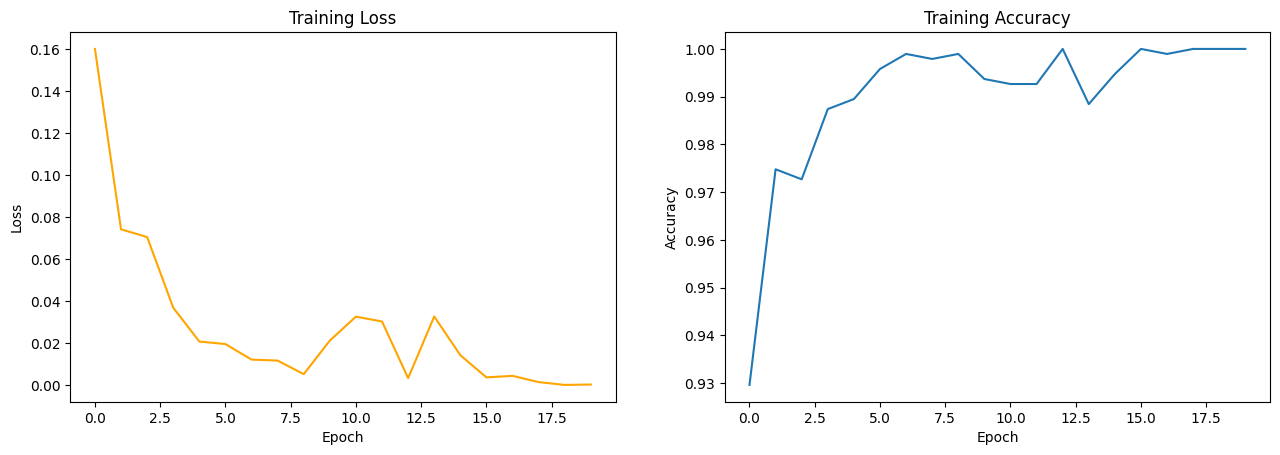

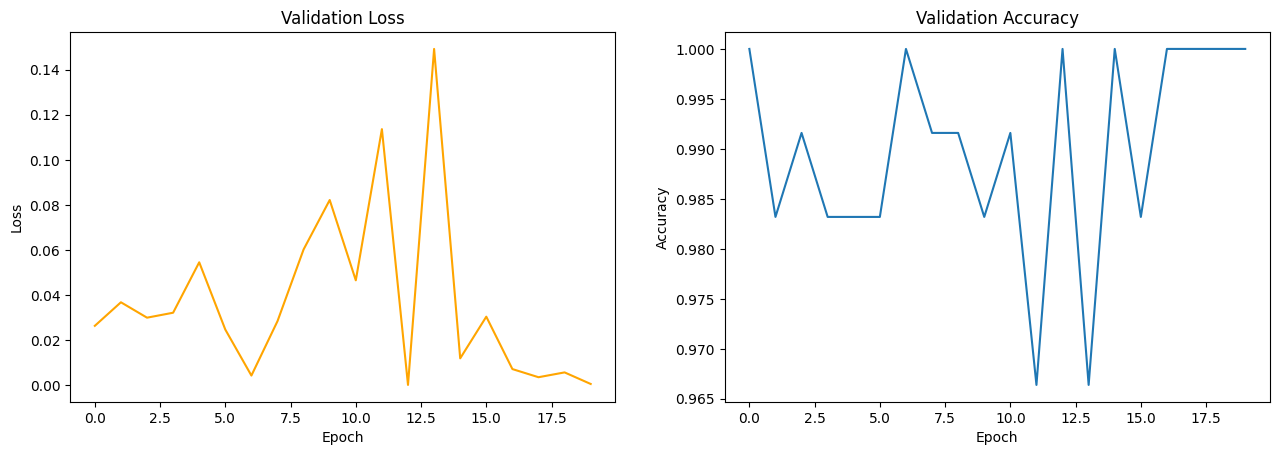

In [25]:
train_model(model, nn.CrossEntropyLoss(), train_dataloader, validation_dataloader, device)

In [35]:
import utils.model, os, shutil, torch
import importlib                    
importlib.reload(utils.model) 
from utils.io import save_image

def evaluate_model(model, dataloader, device=None):
      if device is None:                      
          device = torch.device("cuda" if torch.cuda.is_available() else "cpu")                                                                 
      model.eval()                                                                                                                              
      tp = tn = fp = fn = 0                                                                                                                     
      with torch.no_grad():                                                                                                                     
          for images, labels in dataloader:                                                                                                     
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              _, predicted = torch.max(outputs, 1)                                                                                              
              tp += sum((p == t == 1) for p, t in zip(predicted, labels))
              tn += sum((p == t == 0) for p, t in zip(predicted, labels))                                                                       
              fp += sum(((p == 1) & (t == 0)) for p, t in zip(predicted, labels))
              fn += sum(((p == 0) & (t == 1)) for p, t in zip(predicted, labels))                                                               
      precision = tp / (tp + fp)              
      recall    = tp / (tp + fn)                                                                                                                
      acc       = (tp + tn) / len(dataloader.dataset)                                                                                           
      f1_score  = 2 * ((precision * recall) / (precision + recall))                                                                             
      if torch.isnan(f1_score): f1_score = 0                                                                                                    
      f2_score  = 5 * ((precision * recall) / (4 * precision + recall))                                                                         
      if torch.isnan(f2_score): f2_score = 0  
      return acc * 100, f1_score, f2_score, recall * 100   

# Patch the module so no import can overwrite this
utils.model.evaluate_model = evaluate_model


In [36]:
train_acc, train_f1, train_f2, train_r = evaluate_model(model, train_dataloader)
val_acc, val_f1, val_f2, val_r = evaluate_model(model, validation_dataloader)
test_acc, test_f1, test_f2, test_r = evaluate_model(model, test_dataloader)

In [37]:
print(f"Train | Accuracy: {train_acc:.2f}% | F1_Score: {train_f1:.2f} | F2_Score: {train_f2:.2f} | Anomaly Detection: {train_r:.2f}%")
print(f"  Val | Accuracy: {val_acc:.2f}% | F1_Score: {val_f1:.2f} | F2_Score: {val_f2:.2f} | Anomaly Detection: {val_r:.2f}%")
print(f" Test | Accuracy: {test_acc:.2f}% | F1_Score: {test_f1:.2f} | F2_Score: {test_f2:.2f} | Anomaly Detection: {test_r:.2f}%")

Train | Accuracy: 100.00% | F1_Score: 1.00 | F2_Score: 1.00 | Anomaly Detection: 100.00%
  Val | Accuracy: 100.00% | F1_Score: 1.00 | F2_Score: 1.00 | Anomaly Detection: 100.00%
 Test | Accuracy: 99.16% | F1_Score: 0.97 | F2_Score: 0.99 | Anomaly Detection: 100.00%


In [39]:
from utils.io import save_model                                                                                                               
import os                                                                                                                                     
                                                                                                                                                
os.makedirs("/content/drive/MyDrive/DiabeticRetinopathyDL/models", exist_ok=True)                                                             
save_model(model, "efficientnet_b0", 20, lr=0.001, dir="/content/drive/MyDrive/DiabeticRetinopathyDL/models") 

Saved efficientnet_b0_20_lr0.001-20260414.pt to /content/drive/MyDrive/DiabeticRetinopathyDL/models/efficientnet_b0_20_lr0.001-20260414.pt
